## 1. Dataset Understanding & Analysis
### Data Loading

In [1]:
import pandas as pd

train_df = pd.read_csv("/content/sample_data/train.csv")
test_df = pd.read_csv("/content/sample_data/test.csv")

print(train_df.shape)
print(test_df.shape)

train_df.head()

(891, 12)
(418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:
# Data Types and information about all the columns

train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [3]:
# Summary Statistics
train_df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
PassengerId,891.0,NaN,NaN,NaN,446.0,257.353842,1.0,223.5,446.0,668.5,891.0
Survived,891.0,NaN,NaN,NaN,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
Pclass,891.0,NaN,NaN,NaN,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
Name,891,891,"Dooley, Mr. Patrick",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,714.0,NaN,NaN,NaN,29.699118,14.526497,0.42,20.125,28.0,38.0,80.0
SibSp,891.0,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0
Parch,891.0,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0
Ticket,891,681,347082,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fare,891.0,NaN,NaN,NaN,32.204208,49.693429,0.0,7.9104,14.4542,31.0,512.3292


In [4]:
# Missing Value Analysis
missing = train_df.isnull().sum().sort_values(ascending=False)
print(missing)

Cabin          687
Age            177
Embarked         2
PassengerId      0
Name             0
Pclass           0
Survived         0
Sex              0
Parch            0
SibSp            0
Fare             0
Ticket           0
dtype: int64


### Challenges
1. Missing Data
Cabin heavily missing
Age moderately missing
2. Feature Engineering Needed

Name contains titles:

Mr
Mrs
Miss
Master
Dr

Very predictive.

3. Mixed Data Types

Need encoding.

4. Potential Leakage

PassengerId should not be used.

5. Small Dataset

Only 891 rows.

Risk of overfitting.

In [5]:
# Class Distribution

train_df["Survived"].value_counts(normalize=True)

,proportion
Survived,
0,0.616162
1,0.383838


## Business / Domain Understanding

Goal:

Predict survival probability based on passenger characteristics.

Real-world analog:

Emergency evacuation systems
Risk prediction
Insurance modeling
Safety analytics

## 2. Exploratory Data Analysis (EDA)
### Imports

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

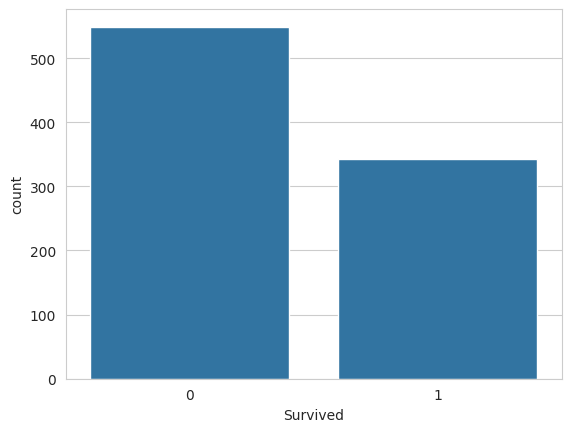

In [7]:
# Survival Distribution
sns.countplot(data=train_df, x = "Survived")
plt.show()


We understand that, more passangers are died.

### Gender vs Survival

<Axes: xlabel='Sex', ylabel='count'>

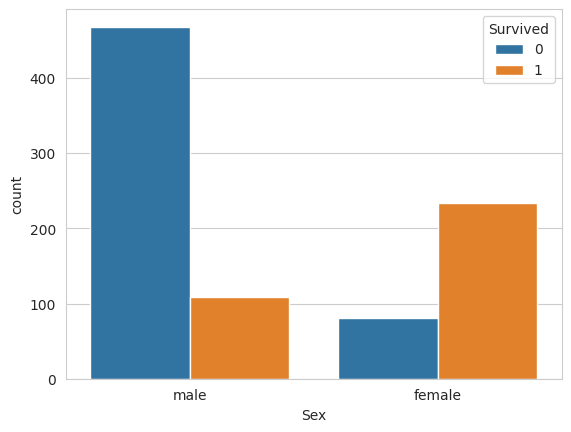

In [8]:
sns.countplot(
    data = train_df,
    x = "Sex",
    hue = "Survived"
)

### Passanger vs Survival

<Axes: xlabel='Pclass', ylabel='count'>

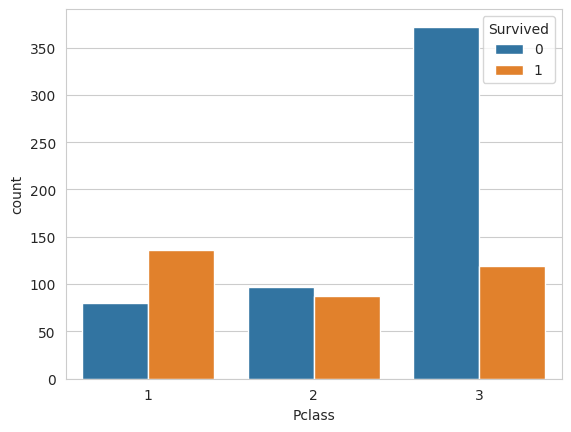

In [9]:
sns.countplot(
    data = train_df,
    x = "Pclass",
    hue = "Survived"
)

Insight:

Higher class passengers survived more.

### Age Distribution

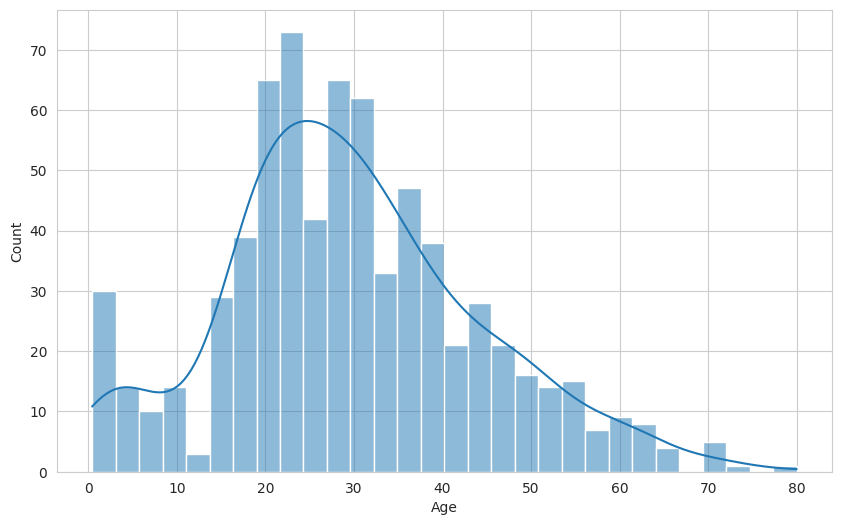

In [10]:
plt.figure(figsize=(10, 6))

sns.histplot(
    train_df['Age'],
    kde = True,
    bins = 30
)

plt.show()

### Fare Distribution

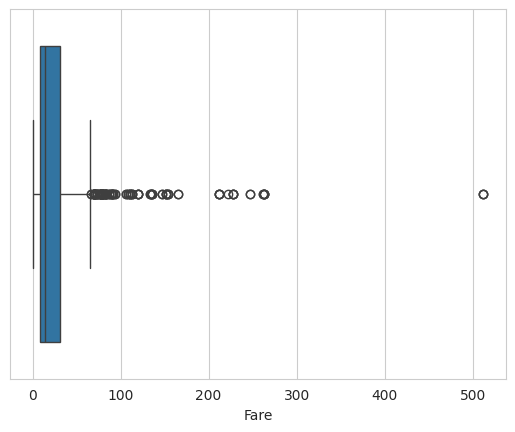

In [11]:
sns.boxplot(x = train_df['Fare'])
plt.show()

Observation:

Strong right skew.

Outliers present.

## Correlation Matrix

<Axes: >

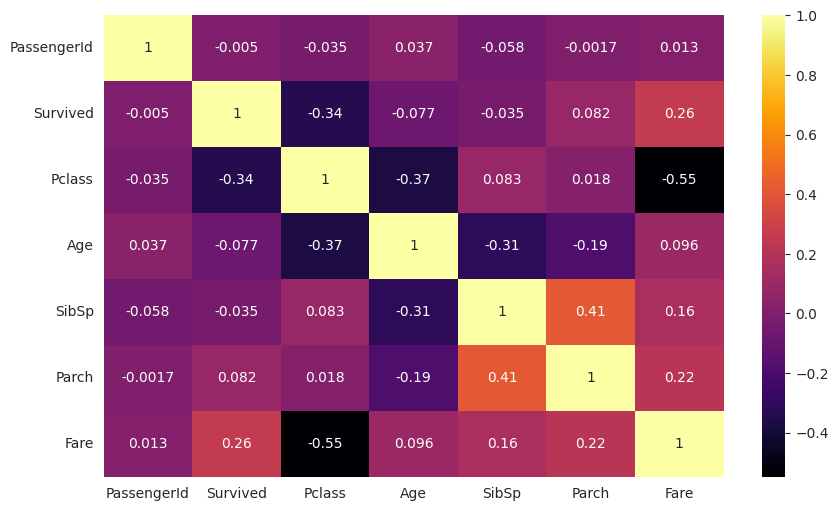

In [12]:
numeric_cols = train_df.select_dtypes(include = ['int64', 'float64'])

corr = numeric_cols.corr()

plt.figure(figsize=(10, 6))

sns.heatmap(
    corr,
    annot = True,
    cmap = "inferno"
)

<Axes: xlabel='Pclass', ylabel='Sex'>

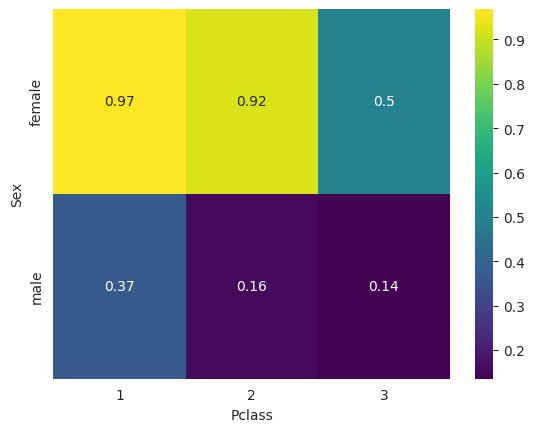

In [13]:
# Survival Heaqtmap

pivot = train_df.pivot_table(
    values = "Survived",
    index = "Sex",
    columns = "Pclass"
)

sns.heatmap(
    pivot,
    annot = True,
    cmap = "viridis"
)

Key Insight:

Female + First Class = highest survival.

## 3. Feature Engineering

In [14]:
#Family Size
train_df["FamilySize"] = train_df["SibSp"] + train_df["Parch"] + 1

#Is Alone?
train_df["IsAlone"] = (
    train_df["FamilySize"] == 1
).astype(int)

In [15]:
# Cabin Known
train_df["CabinKnown"] = (
    train_df["Cabin"].notnull()
).astype(int)

In [16]:
# Ticket Group Size
ticket_count = train_df["Ticket"].value_counts()

train_df["TicketGroup"] = (
    train_df["Ticket"].map(ticket_count)
)

## Production Preprocessing Pipeline

In [17]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

In [18]:
train_df.head(1)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilySize,IsAlone,CabinKnown,TicketGroup
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.25,NaN,S,2,0,0,1


In [19]:
numeric_features = [
    'Age',
    'Fare',
    'FamilySize',
    'TicketGroup'
]

categorical_features = [
    'Sex',
    'Embarked',
    'Title',
    'pclass'
]


In [20]:
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numeric_features),
    ('cat', categorical_pipeline, categorical_features)
])


## 4. Modeling Strategy
## Baseline Models -
### Logistic Regression
### Decision Tree
### Random Forest
### Gradient Boosting
### XGBoost

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

How Random Forest Works

A Random Forest creates many decision trees.

Each tree:

Uses random rows
Uses random features
Makes prediction


### Cross Validation

In [22]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

In [23]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [24]:
!pip install optuna

import optuna

In [25]:
X = train_df.drop("Survived", axis=1)
y = train_df["Survived"]

In [26]:
print(train_df.columns.tolist())
train_df['Title'] = train_df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
train_df[['Name', 'Title']].head()

['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'FamilySize', 'IsAlone', 'CabinKnown', 'TicketGroup']


<>:2: SyntaxWarning: invalid escape sequence '\.'
<>:2: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipykernel_8829/103221186.py:2: SyntaxWarning: invalid escape sequence '\.'
  train_df['Title'] = train_df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)


,Name,Title
0,"Braund, Mr. Owen Harris",Mr
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",Mrs
2,"Heikkinen, Miss. Laina",Miss
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",Mrs
4,"Allen, Mr. William Henry",Mr


In [27]:
features = [
    'Pclass',
    'Sex',
    'Age',
    'Fare',
    'Embarked',
    'FamilySize',
    'IsAlone',
    'CabinKnown',
    'TicketGroup',
    'Title'
]

X = train_df[features]
y = train_df['Survived']

In [28]:
def objective(trial):

    params = {

        "n_estimators":
            trial.suggest_int(
                "n_estimators",
                100,
                1000
            ),

        "max_depth":
            trial.suggest_int(
                "max_depth",
                3,
                10
            ),

        "learning_rate":
            trial.suggest_float(
                "learning_rate",
                0.01,
                0.3
            ),

        "subsample":
            trial.suggest_float(
                "subsample",
                0.6,
                1.0
            ),

        "colsample_bytree":
            trial.suggest_float(
                "colsample_bytree",
                0.6,
                1.0
            )
    }

    pipeline = Pipeline([

        (
            "preprocessor",
            preprocessor
        ),

        (
            "model",
            XGBClassifier(
                **params,
                random_state=42,
                eval_metric="logloss"
            )
        )
    ])

    score = cross_val_score(
        pipeline,
        X,
        y,
        cv=cv,
        scoring="accuracy"
    ).mean()

    return score

In [29]:
def objective(trial):

    # Re-extract Title here to ensure it's always present in train_df when X is formed within objective
    # This is a temporary fix for the notebook's current state where Title is created after X.
    # Ideally, Title extraction would be done earlier in the feature engineering section.
    train_df['Title'] = train_df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

    # Redefine features and preprocessor here to ensure consistency and self-containment for Optuna's trials
    numeric_features = [
        'Age',
        'Fare',
        'FamilySize',
        'TicketGroup',
        'CabinKnown',
        'IsAlone'
    ]

    categorical_features = [
        'Sex',
        'Embarked',
        'Title',
        'Pclass' # Corrected 'pclass' to 'Pclass'
    ]

    # Define X using all relevant features after all engineering steps
    all_features = list(set(numeric_features + categorical_features))
    X = train_df[all_features]
    y = train_df['Survived']

    numeric_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])

    categorical_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ])

    preprocessor = ColumnTransformer([
        ('num', numeric_pipeline, numeric_features),
        ('cat', categorical_pipeline, categorical_features)
    ])

    params = {
        "n_estimators":
            trial.suggest_int(
                "n_estimators",
                100,
                1000
            ),

        "max_depth":
            trial.suggest_int(
                "max_depth",
                3,
                10
            ),

        "learning_rate":
            trial.suggest_float(
                "learning_rate",
                0.01,
                0.3
            ),

        "subsample":
            trial.suggest_float(
                "subsample",
                0.6,
                1.0
            ),

        "colsample_bytree":
            trial.suggest_float(
                "colsample_bytree",
                0.6,
                1.0
            )
    }

    pipeline = Pipeline([
        (
            "preprocessor",
            preprocessor
        ),

        (
            "model",
            XGBClassifier(
                **params,
                random_state=42,
                eval_metric="logloss"
            )
        )
    ])

    score = cross_val_score(
        pipeline,
        X,
        y,
        cv=cv,
        scoring="accuracy"
    ).mean()

    return score

study = optuna.create_study(
    direction="maximize"
)

study.optimize(
    objective,
    n_trials=50
)

<>:6: SyntaxWarning: invalid escape sequence '\.'
<>:6: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipykernel_8829/562990772.py:6: SyntaxWarning: invalid escape sequence '\.'
  train_df['Title'] = train_df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
[I 2026-06-11 09:40:26,335] A new study created in memory with name: no-name-c3083fc9-b3f7-41e3-9759-490cf45f734a
[I 2026-06-11 09:40:28,768] Trial 0 finished with value: 0.805793735484276 and parameters: {'n_estimators': 552, 'max_depth': 8, 'learning_rate': 0.22332652051388133, 'subsample': 0.6191848090632844, 'colsample_bytree': 0.8374286931803115}. Best is trial 0 with value: 0.805793735484276.
[I 2026-06-11 09:40:33,418] Trial 1 finished with value: 0.8215115184232001 and parameters: {'n_estimators': 347, 'max_depth': 7, 'learning_rate': 0.19375646079007522, 'subsample': 0.7746588332330006, 'colsample_bytree': 0.6148462804372655}. Best is trial 1 with value: 0.8215115184232001.
[I 2026-06-11 09:40:45,163] Trial 2 finished 

In [30]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (OneHotEncoder, StandardScaler)
from xgboost import XGBClassifier

# Define the features lists again, ensuring correct casing and inclusion of all engineered features
numeric_features = [
    'Age',
    'Fare',
    'FamilySize',
    'TicketGroup',
    'CabinKnown',
    'IsAlone'
]

categorical_features = [
    'Sex',
    'Embarked',
    'Title',
    'Pclass' # Corrected 'pclass' to 'Pclass'
]

# Re-create the preprocessor within this cell to use the corrected feature lists
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numeric_features),
    ('cat', categorical_pipeline, categorical_features)
])

# Split the data into training and validation sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

model = Pipeline([

    ('preprocessor',
     preprocessor),

    ('classifier',
     XGBClassifier(
         n_estimators=500,
         max_depth=5,
         learning_rate=0.05,
         subsample=0.8,
         colsample_bytree=0.8,
         random_state=42
     ))
])

model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Fare', 'FamilySize',
                                                   'TicketGroup', 'CabinKnown',
                                                   'IsAlone']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=5, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=500, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [31]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

preds = model.predict(X_test)

print(
    accuracy_score(
        y_test,
        preds
    )
)

print(
    classification_report(
        y_test,
        preds
    )
)

0.7877094972067039
              precision    recall  f1-score   support

           0       0.83      0.83      0.83       110
           1       0.72      0.72      0.72        69

    accuracy                           0.79       179
   macro avg       0.78      0.78      0.78       179
weighted avg       0.79      0.79      0.79       179



<Axes: >

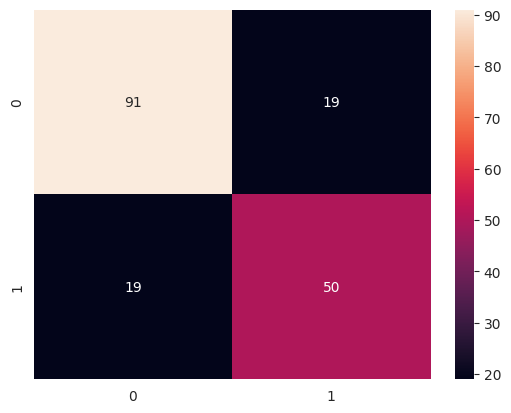

In [32]:
sns.heatmap(
    confusion_matrix(
        y_test,
        preds
    ),
    annot=True,
    fmt='d'
)

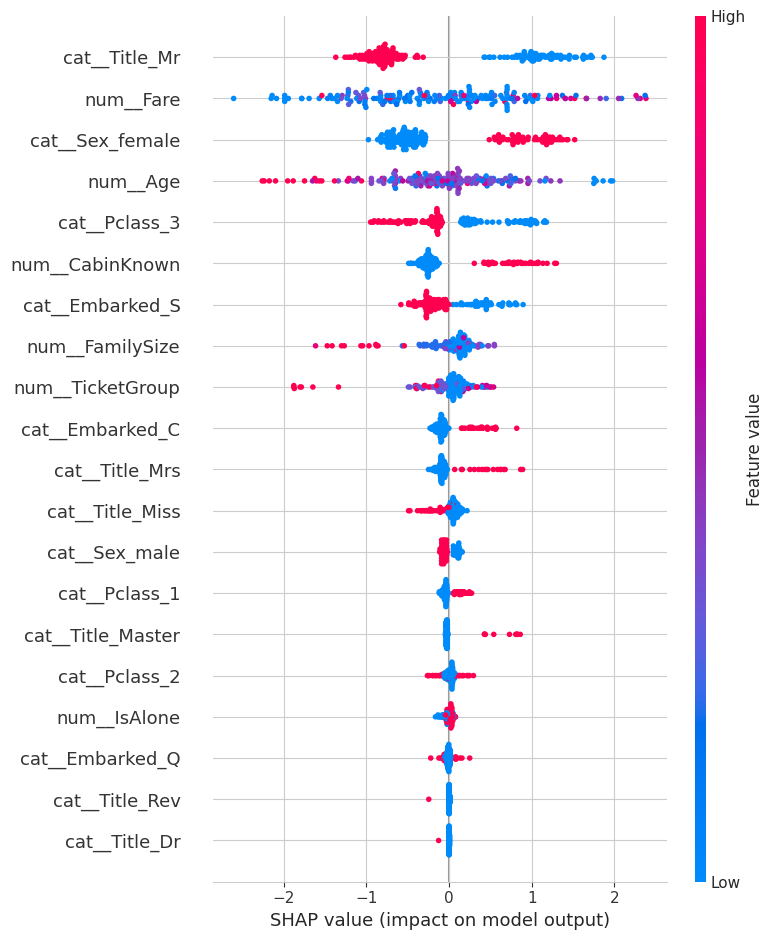

In [33]:
import shap
import pandas as pd

# The trained XGBoost model is part of the 'model' pipeline
trained_xgb_model = model.named_steps['classifier']

explainer = shap.TreeExplainer(
    trained_xgb_model
)

# Get the preprocessor from the trained pipeline
pipeline_preprocessor = model.named_steps['preprocessor']

# Transform X_test using the preprocessor
X_test_preprocessed_array = pipeline_preprocessor.transform(X_test)

# Attempt to get feature names from the fitted preprocessor for better plotting
try:
    feature_names = pipeline_preprocessor.get_feature_names_out()
    X_test_preprocessed_df = pd.DataFrame(X_test_preprocessed_array, columns=feature_names)
except Exception as e:
    print(f"Warning: Could not get detailed feature names from preprocessor: {e}. Using generic names for SHAP plot.")
    X_test_preprocessed_df = pd.DataFrame(X_test_preprocessed_array)

shap_values = explainer.shap_values(X_test_preprocessed_df)

shap.summary_plot(
    shap_values,
    X_test_preprocessed_df
)

In [34]:
errors = X_test[
    preds != y_test
]

## Resources

### Dataset & Competition
* [Kaggle Titanic: Machine Learning from Disaster](https://www.kaggle.com/c/titanic) - Official competition page and dataset description.

### Libraries Used
* [Scikit-Learn Documentation](https://scikit-learn.org/stable/) - Comprehensive guide for Pipelines, ColumnTransformers, and model evaluation.
* [XGBoost Documentation](https://xgboost.readthedocs.io/) - Detailed information on the Gradient Boosting framework used for the final model.
* [Optuna Documentation](https://optuna.readthedocs.io/) - Hyperparameter optimization framework used for tuning the model.
* [SHAP (SHapley Additive exPlanations)](https://shap.readthedocs.io/) - Documentation for the model interpretability tool used to visualize feature importance.